In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from enum import Enum

# Vectorized BackTesting
Backtesting is an essential part of trading. Indeed, it is important to understand the behavior of your strategy in the past to be able to consider those of future.
### Content

* Sortino Beta Alpha
* Drawdown 
* Create function BackTest to evaluate the strategy in the later sections

## Load data
### GOLD data for the primary strategy

In [2]:
df_GOLD_Raw = pd.read_parquet(f"../Data/GOLD_1M.parquet")
df_GOLD_Raw.head()

,open,high,low,close,volume
time,,,,,
2019-10-15 12:13:00,1492.87,1493.36,1492.77,1493.33,62
2019-10-15 12:14:00,1493.36,1493.47,1493.06,1493.07,47
2019-10-15 12:15:00,1493.09,1493.28,1492.97,1493.07,70
2019-10-15 12:16:00,1493.08,1493.35,1493.07,1493.35,28
2019-10-15 12:17:00,1493.30,1493.36,1493.14,1493.28,38


### EURUSD data for the performance test

In [3]:
df_EURUSD_Raw = pd.read_parquet(f"../Data/EURUSD_M1.parquet")
df_EURUSD_Raw.head()

,open,high,low,close,volume
time,,,,,
2020-01-02 00:05:00,1.12118,1.12118,1.12109,1.12109,7
2020-01-02 00:06:00,1.12109,1.12109,1.12105,1.12108,4
2020-01-02 00:07:00,1.12110,1.12110,1.12109,1.12110,3
2020-01-02 00:08:00,1.12109,1.12109,1.12101,1.12101,4
2020-01-02 00:09:00,1.12102,1.12102,1.12074,1.12074,4


## Performance measures
### Sortino
The sortino ratio is a statistic similar to the sharpe ratio with the same interpretation. It takes an asset's or portfolio's return and subtracts the risk-free rate. It then divides that amount by the asset's downside deviation.  <br>
<p align="center">
$Sortino = \frac{\mu }{\sigma_{down}}$
<p> <br>

*   SortinoRatio < 0 : Not profitable investissement because you gains is negative.
*   SortinoRatio < 1 : Profitable investissement but the risk of the investissement is higher than the returns.
*   SortinoRatio > 1: Very good investissement because the risk is lower than the returns.


In [4]:
return_serie = df_GOLD_Raw["close"].pct_change(1).dropna()
return_serie.name = "return"

# Compute the sortino
mean = np.mean(return_serie) #252
vol = np.std(return_serie[return_serie<0]) #sqrt(252)
sortino = np.sqrt(252) * mean/vol

print(f"Sortino: {'%.3f' % sortino}")

Sortino: 0.037


### Beta
The beta is a statistic that indicates the relationship between the variations of our portfolio and those of the market which is represented by an index (for example SP500). <br>

<p align="center">
$Beta = \frac{Cov(r_{M},r_{PF}) }{Var(r_{M})}$
<p> <br>



*   abs(Beta) < 1: It is good because it means that your portfolio have a less variation than the index. (If beta=0.9 this means that if the index varies of 1 the portfolio varies by 0.9)
*   abs(Beta) > 1: It is not a good thing because it means that your portfolio have a higher variation than the index. (If beta=1.1 this means that if the index varies of 1 the portfolio varies by 1.1)

**abs(-x) = x = abs(x) (abs gives only the value of the variable not the sign)*


In [5]:
# We need compute the covariance between the market and the portfolio 
eurusd = df_EURUSD_Raw["close"].pct_change(1)
eurusd.name = "EURUSD"

# Remove duplicate timestamps before alignment
return_serie = return_serie[~return_serie.index.duplicated(keep="last")].sort_index()
eurusd = eurusd[~eurusd.index.duplicated(keep="last")].sort_index()

# We concate them to do the covariances
val = pd.concat((return_serie, eurusd), axis=1, join="inner").dropna()

# We compute beta 
cov_var_mat = np.cov(val.values, rowvar=False)
cov = cov_var_mat[0][1]
var = cov_var_mat[1][1]

beta = cov/var

print(f"Beta: {'%.3f' % beta}")

Beta: 0.001


### **Alpha**
Alpha is a statistic that indicates whether the portfolio outperforms the market in terms of risk return. <br>

<p align="center">
$Alpha = r_{PF} - \beta*(r_{PF} - r_{f}) - r_{f}$
<p> <br>


*   alpha > 0: The portfolio outperforms the market in terms of risk return
*   alpha < 0: The portfolio underperforms the market in terms of risk return

In [6]:
class TimeFrame(Enum):
  DAILY = 252
  MIN_1 = 252 * 24 * 60
  MIN_5 = 252 * 24 * 12
  MIN_10 = 252 * 24 * 6
  HOUR_1 = 252 * 24
  HOUR_6 = 252 * 4

selected_timeframe = TimeFrame.MIN_1
print(f"Annualization factor for {selected_timeframe.name}: {selected_timeframe.value}")

Annualization factor for MIN_1: 362880


In [7]:
# We compute alpha 
alpha = (selected_timeframe.value * mean * (1-beta)) * 100
print(f"Alpha: {'%.1f' % alpha}")

Alpha: 18.9


### Drawdown

The drawdown is a measure of the risk of the strategy. An interesting statistic to know the performance of the algorithm is the maximum drawdown. Indeed, it represents the maximum loss of a strategy over a period of time which allows you to understand if the strategy is risky and thus choose it according to your level of risk aversion.

In [8]:
def drawdown_function(serie):

  # We compute Cumsum of the returns
  cum = serie.dropna().cumsum() + 1

  # We compute max of the cumsum on the period (accumulate max) # (1,3,5,3,1) --> (1,3,5,5,5)
  running_max = np.maximum.accumulate(cum)

  # We compute drawdown
  drawdown = cum/running_max - 1
  return drawdown



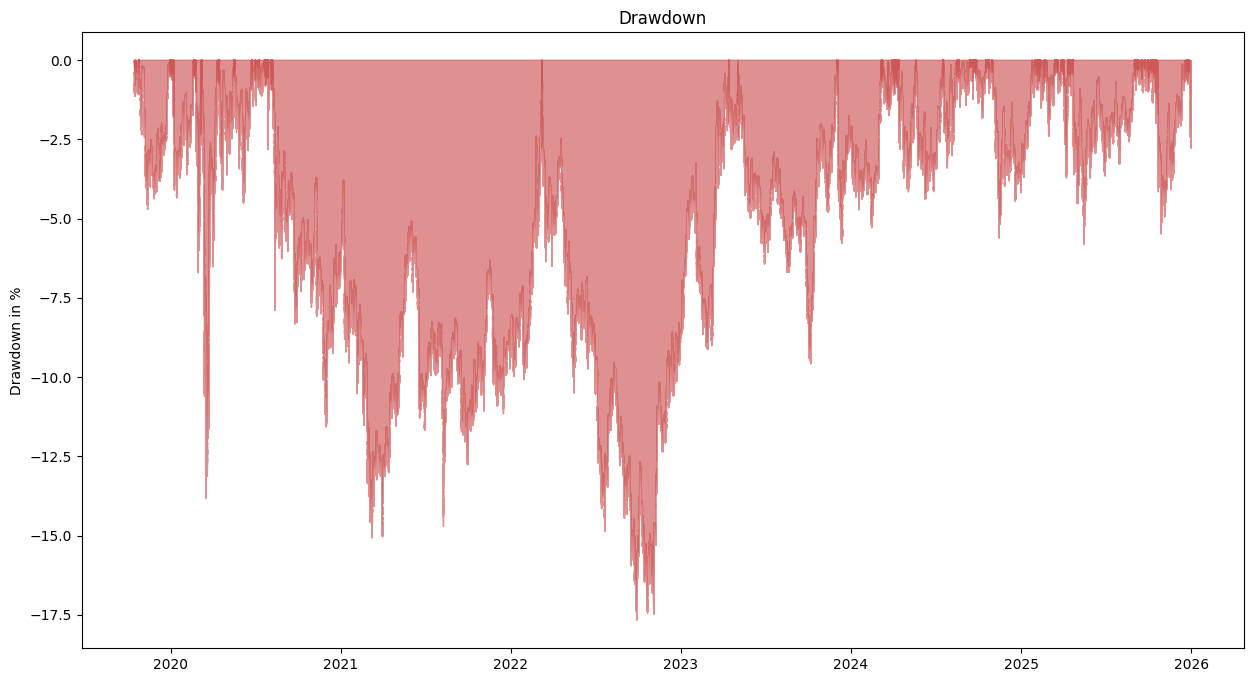

In [9]:
# We compute drawdown
drawdown = drawdown_function(return_serie)

# Adapt figure size
plt.figure(figsize=(15,8))

# Plot the drawdown
plt.fill_between(drawdown.index, drawdown*100, 0,
                 drawdown, color="#CE5757", alpha=0.65)

# Put a title
plt.title("Drawdown")

# Put y label
plt.ylabel("Drawdown in %")

plt.show()


In [10]:
# Computation Max drawdown
max_drawdown = -np.min(drawdown)*100
print(f"Max drawdown: {'%.1f' % max_drawdown} %")

Max drawdown: 17.7 %
